In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

In [33]:
plt.style.use('seaborn-v0_8-darkgrid')


In [34]:
df_train = pd.read_csv('/content/drive/MyDrive/data (1)/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/data (1)/test.csv')

In [35]:
df_train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [36]:
df_train.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [37]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [38]:
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

In [39]:
df_train.set_index('date', inplace=True)
df_test.set_index('date', inplace=True)

In [40]:
df_train.sort_index(inplace=True)
df_test.sort_index(inplace=True)

In [41]:
df_train.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [42]:
print(f"Training data: {df_train.index.min()} to {df_train.index.max()}")

Training data: 2013-01-01 00:00:00 to 2017-01-01 00:00:00


In [43]:
print(f"Training data: {df_test.index.min()} to {df_test.index.max()}")

Training data: 2017-01-01 00:00:00 to 2017-04-24 00:00:00


In [44]:
train_temp = df_train['meantemp']
test_temp = df_test['meantemp']

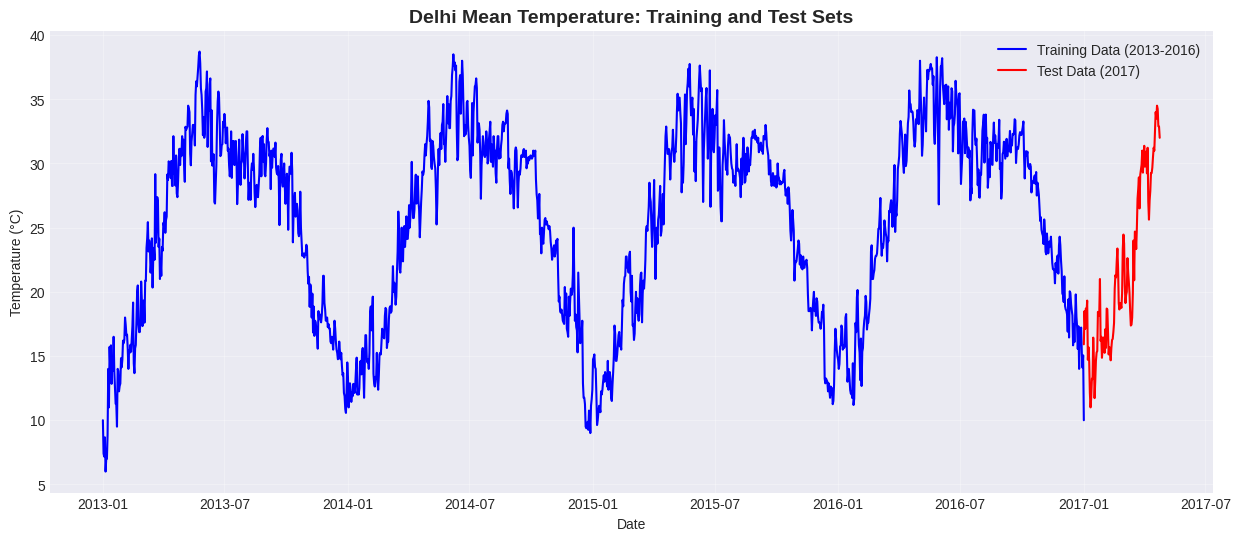

In [45]:
plt.figure(figsize=(15, 6))
plt.plot(train_temp.index, train_temp, label='Training Data (2013-2016)', color='blue')
plt.plot(test_temp.index, test_temp, label='Test Data (2017)', color='red')
plt.title('Delhi Mean Temperature: Training and Test Sets', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

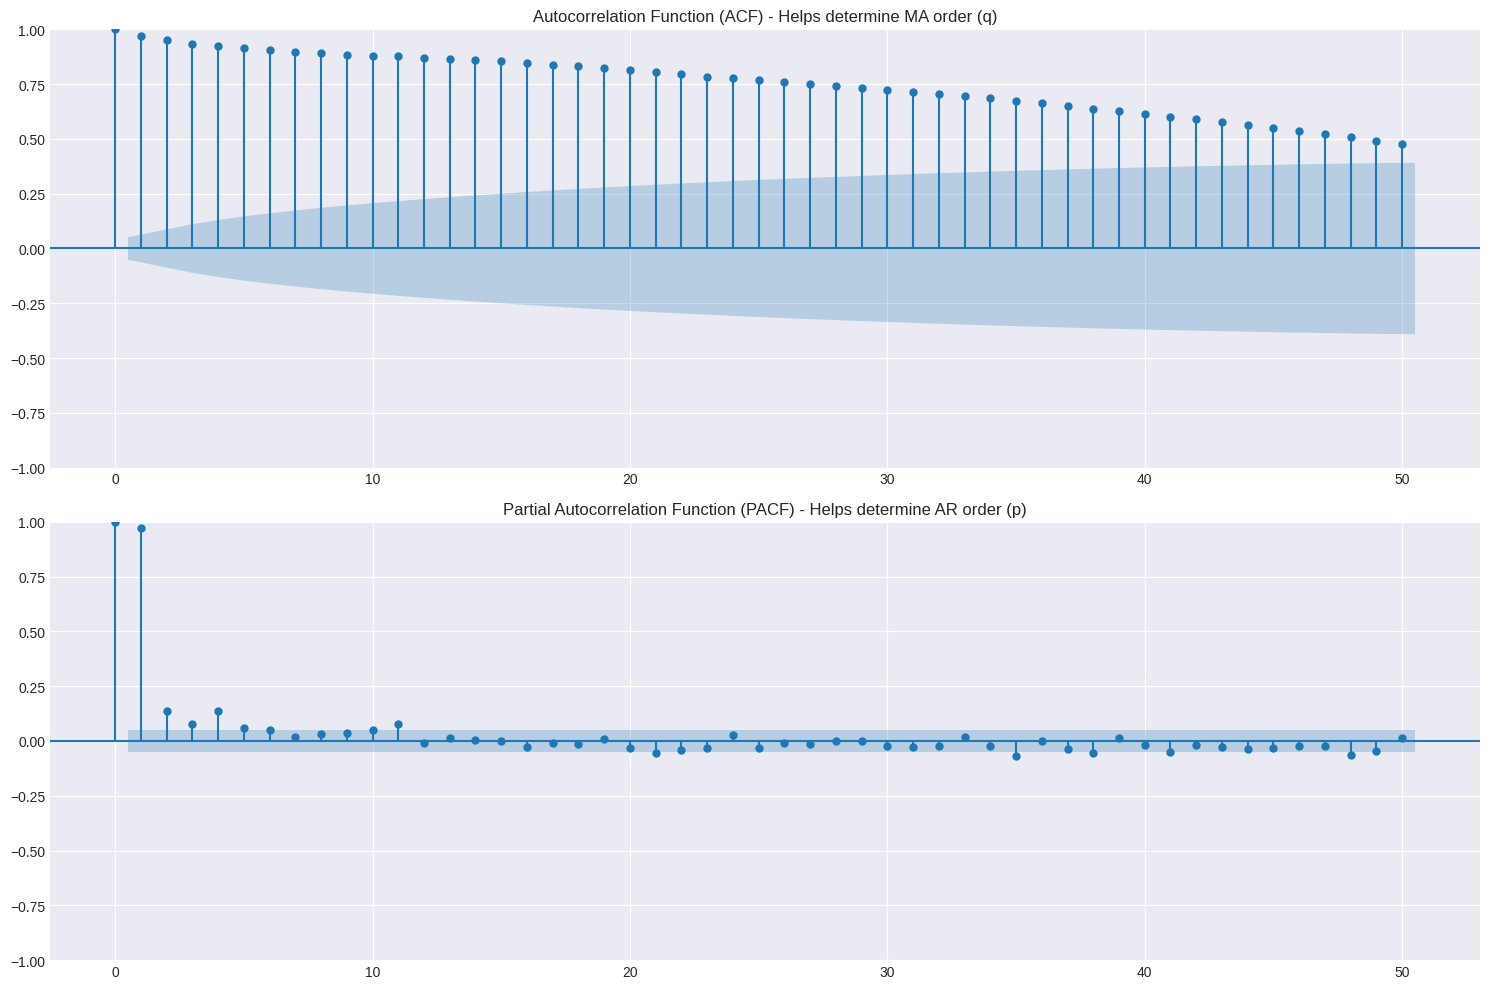

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# ACF plot (helps determine q and Q)
plot_acf(train_temp, lags=50, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) - Helps determine MA order (q)', fontsize=12)

# PACF plot (helps determine p and P)
plot_pacf(train_temp, lags=50, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) - Helps determine AR order (p)', fontsize=12)

plt.tight_layout()
plt.show()

In [47]:
print("Resampling data to monthly frequency for faster training...")
monthly_temp = train_temp.resample('M').mean()
monthly_test = test_temp.resample('M').mean()

print(f"Monthly training data: {len(monthly_temp)} points")
print(f"Monthly test data: {len(monthly_test)} points")

Resampling data to monthly frequency for faster training...
Monthly training data: 49 points
Monthly test data: 4 points


In [48]:
model = SARIMAX(monthly_temp,
                order=(1,1,1),           # (p,d,q)
                seasonal_order=(1,1,1,12), # (P,D,Q,s) with s=12 for monthly
                enforce_stationarity=False,
                enforce_invertibility=False,
                simple_differencing=True)

# Fit the model
sarima_model = model.fit(disp=False)

print("\n✅ Model training complete!")
print("\nModel Summary:")
print(sarima_model.summary().tables[1])


✅ Model training complete!

Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0513      0.676     -0.076      0.939      -1.375       1.273
ma.L1          0.4871      0.639      0.762      0.446      -0.766       1.740
ar.S.L12      -0.9281      0.250     -3.719      0.000      -1.417      -0.439
ma.S.L12      -1.0009   1077.050     -0.001      0.999   -2111.981    2109.979
sigma2         1.3776   1483.837      0.001      0.999   -2906.890    2909.645


In [49]:
fitted_values = sarima_model.fittedvalues
residuals = sarima_model.resid

In [50]:
residuals_clean = residuals.dropna()
fitted_values_clean = fitted_values.dropna()

In [51]:
print(f"Original data points: {len(monthly_temp)}")
print(f"Residuals after removing NaN: {len(residuals_clean)}")
print(f"First few residuals:\n{residuals.head()}")


Original data points: 49
Residuals after removing NaN: 36
First few residuals:
date
2014-02-28   -2.477814
2014-03-31   -0.227208
2014-04-30    0.378970
2014-05-31   -1.514754
2014-06-30    4.582509
Freq: ME, dtype: float64


In [53]:
from scipy import stats


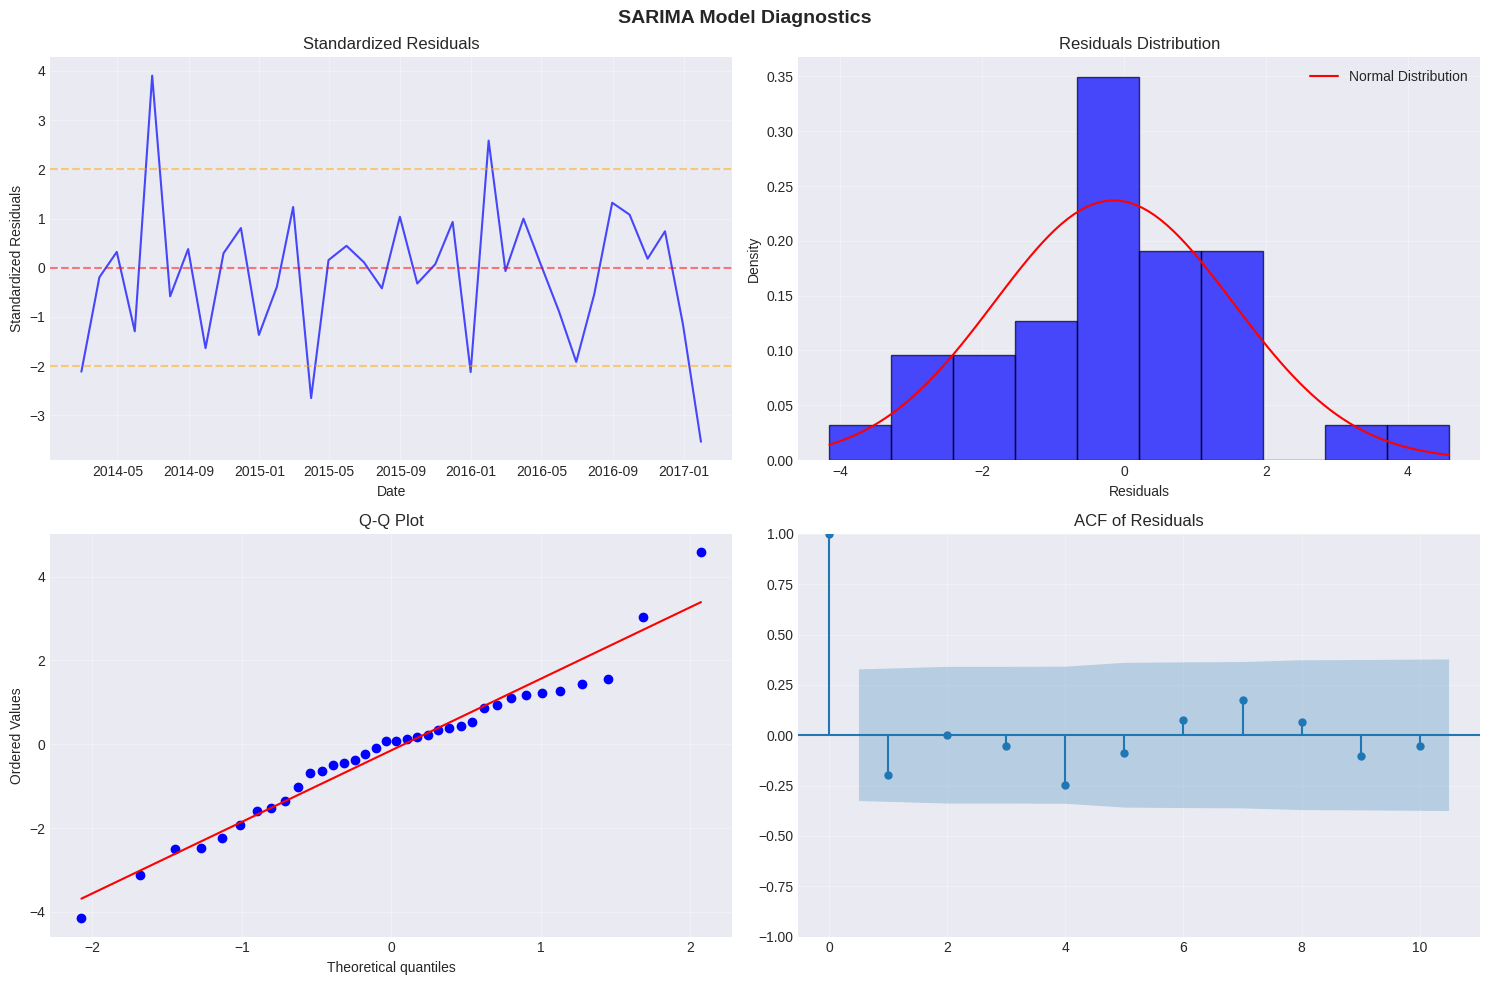

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SARIMA Model Diagnostics', fontsize=14, fontweight='bold')

# 1. Standardized Residuals
standardized_residuals = residuals / np.sqrt(sarima_model.params['sigma2'])
axes[0, 0].plot(standardized_residuals.index, standardized_residuals, color='blue', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].axhline(y=2, color='orange', linestyle='--', alpha=0.5)
axes[0, 0].axhline(y=-2, color='orange', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Standardized Residuals')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=10, edgecolor='black', alpha=0.7, color='blue', density=True)
axes[0, 1].set_title('Residuals Distribution')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)

# Add normal distribution curve for comparison
from scipy.stats import norm
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, norm.pdf(x, residuals.mean(), residuals.std()), 'r-', label='Normal Distribution')
axes[0, 1].legend()

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

# 4. ACF of residuals
plot_acf(residuals.dropna(), lags=10, ax=axes[1, 1])
axes[1, 1].set_title('ACF of Residuals')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [55]:
predictions = sarima_model.predict(start=len(monthly_temp),
                                   end=len(monthly_temp) + len(monthly_test) - 1)


In [56]:
predictions.index = monthly_test.index


In [58]:
comparison = pd.DataFrame({
    'Actual': monthly_test,
    'Predicted': predictions,
    'Error': monthly_test - predictions,
    'Absolute_Error': abs(monthly_test - predictions),
    'Percentage_Error': abs((monthly_test - predictions) / monthly_test) * 100
})
print(comparison.round(2))


            Actual  Predicted  Error  Absolute_Error  Percentage_Error
date                                                                  
2017-01-31   15.71       3.77  11.94           11.94             76.01
2017-02-28   18.35       0.65  17.70           17.70             96.47
2017-03-31   23.75      -3.36  27.12           27.12            114.16
2017-04-30   30.75      -0.95  31.70           31.70            103.08


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(monthly_test, predictions)
rmse = np.sqrt(mean_squared_error(monthly_test, predictions))
mape = np.mean(np.abs((monthly_test - predictions) / monthly_test)) * 100
r2 = r2_score(monthly_test, predictions)

print(f"\n📈 PERFORMANCE METRICS:")
print(f"{'Mean Absolute Error (MAE):':<30} {mae:.2f}°C")
print(f"{'Root Mean Square Error (RMSE):':<30} {rmse:.2f}°C")
print(f"{'Mean Absolute Percentage Error (MAPE):':<30} {mape:.2f}%")
print(f"{'R² Score:':<30} {r2:.3f}")

print(f"\n📊 INTERPRETATION:")
print(f"• On average, predictions are off by {mae:.2f}°C")
print(f"• The model explains {r2*100:.1f}% of the temperature variation")
print(f"• Average percentage error is {mape:.1f}%")


📈 PERFORMANCE METRICS:
Mean Absolute Error (MAE):     22.11°C
Root Mean Square Error (RMSE): 23.43°C
Mean Absolute Percentage Error (MAPE): 97.43%
R² Score:                      -15.575

📊 INTERPRETATION:
• On average, predictions are off by 22.11°C
• The model explains -1557.5% of the temperature variation
• Average percentage error is 97.4%


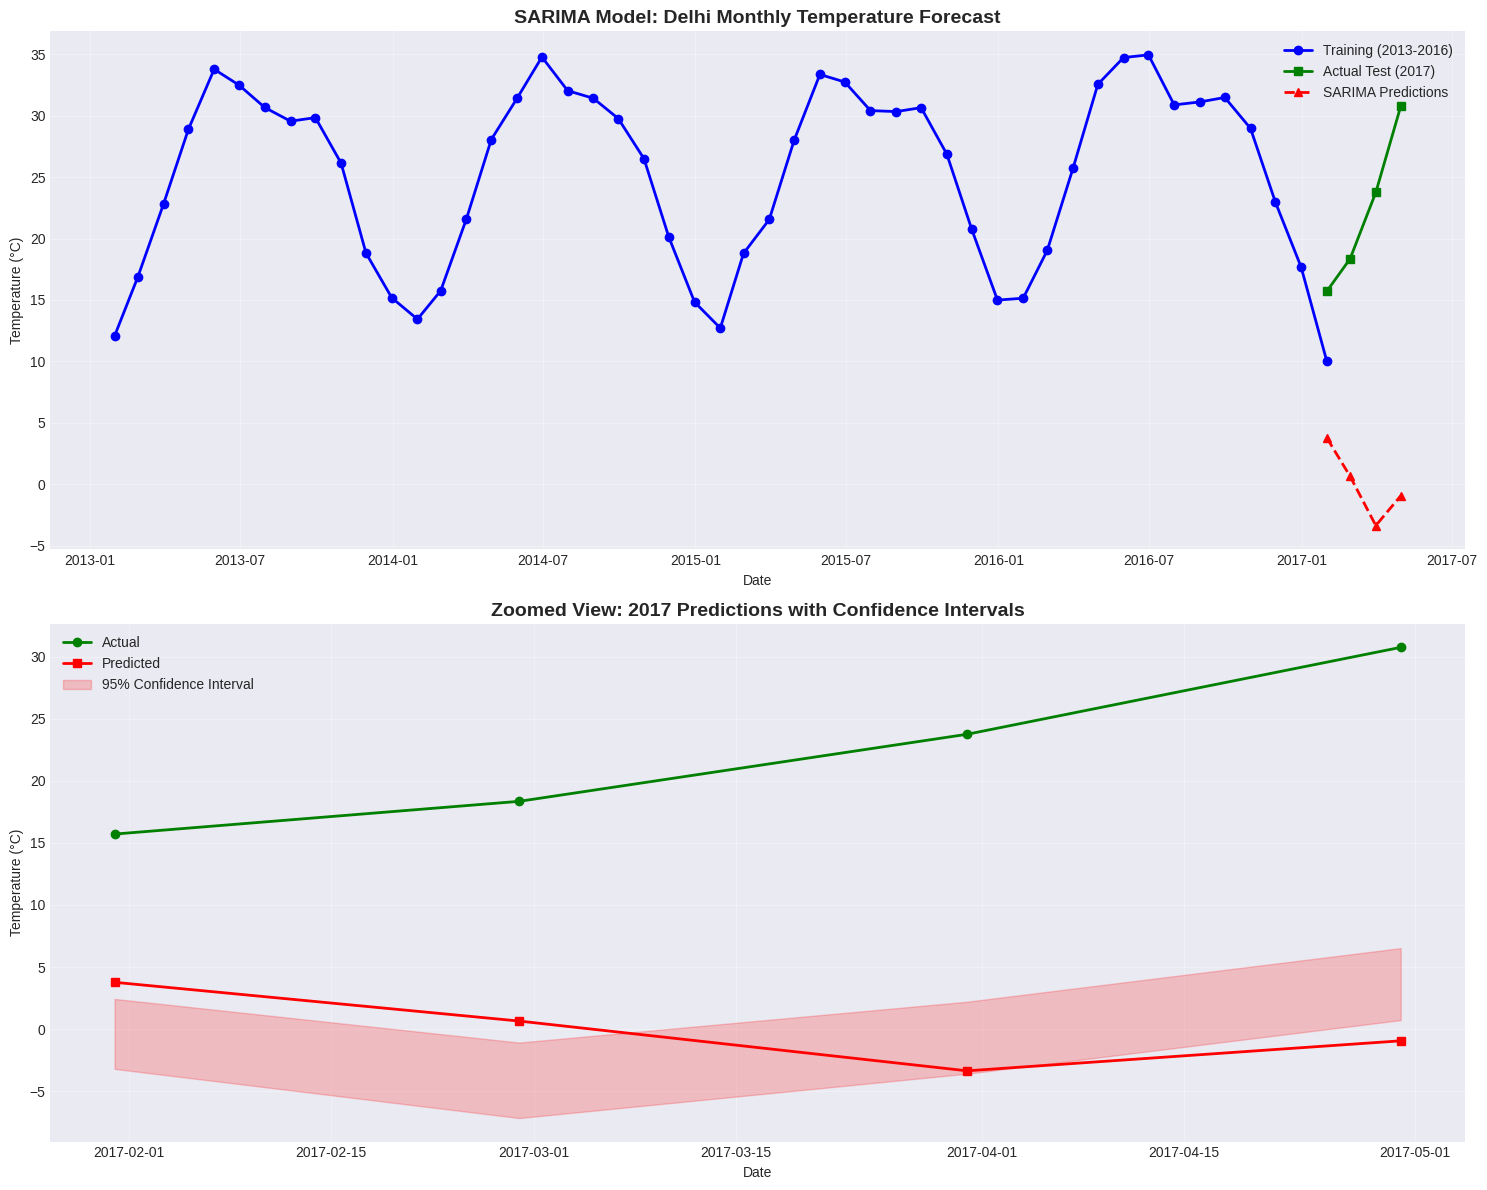

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Full time series with predictions
axes[0].plot(monthly_temp.index, monthly_temp, label='Training (2013-2016)', color='blue', linewidth=2, marker='o')
axes[0].plot(monthly_test.index, monthly_test, label='Actual Test (2017)', color='green', linewidth=2, marker='s')
axes[0].plot(predictions.index, predictions, label='SARIMA Predictions', color='red', linestyle='--', linewidth=2, marker='^')
axes[0].set_title('SARIMA Model: Delhi Monthly Temperature Forecast', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Zoomed view of test period with confidence intervals
# Get prediction intervals
forecast_results = sarima_model.get_forecast(steps=len(monthly_test))
confidence_intervals = forecast_results.conf_int(alpha=0.05)  # 95% confidence interval
confidence_intervals.index = monthly_test.index

axes[1].plot(monthly_test.index, monthly_test, label='Actual', color='green', linewidth=2, marker='o')
axes[1].plot(predictions.index, predictions, label='Predicted', color='red', linewidth=2, marker='s')
axes[1].fill_between(confidence_intervals.index,
                     confidence_intervals.iloc[:, 0],
                     confidence_intervals.iloc[:, 1],
                     color='red', alpha=0.2, label='95% Confidence Interval')
axes[1].set_title('Zoomed View: 2017 Predictions with Confidence Intervals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


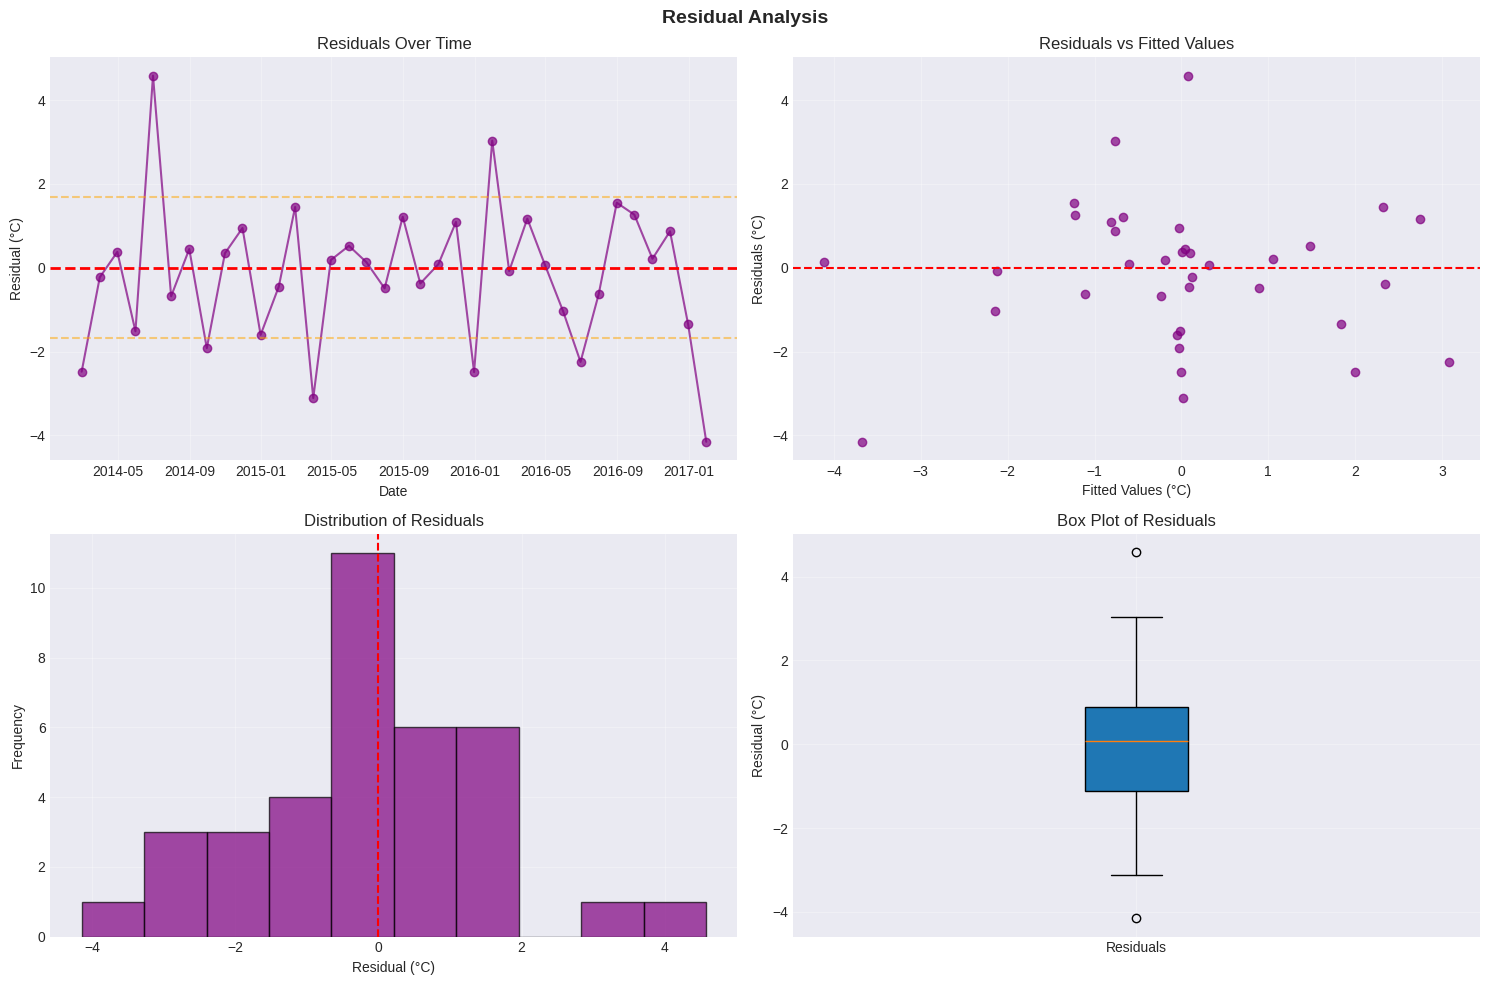

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

# Residuals over time
axes[0, 0].plot(residuals_clean.index, residuals_clean, color='purple', marker='o', linestyle='-', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].axhline(y=residuals_clean.std(), color='orange', linestyle='--', alpha=0.5)
axes[0, 0].axhline(y=-residuals_clean.std(), color='orange', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual (°C)')
axes[0, 0].grid(True, alpha=0.3)

# Residuals vs Fitted values
axes[0, 1].scatter(fitted_values_clean, residuals_clean, alpha=0.7, color='purple')
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Fitted Values')
axes[0, 1].set_xlabel('Fitted Values (°C)')
axes[0, 1].set_ylabel('Residuals (°C)')
axes[0, 1].grid(True, alpha=0.3)

# Histogram of residuals
axes[1, 0].hist(residuals_clean, bins=10, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].axvline(x=0, color='red', linestyle='--')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].set_xlabel('Residual (°C)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Box plot of residuals
axes[1, 1].boxplot(residuals_clean, vert=True, patch_artist=True)
axes[1, 1].set_title('Box Plot of Residuals')
axes[1, 1].set_ylabel('Residual (°C)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticklabels(['Residuals'])

plt.tight_layout()
plt.show()

In [64]:
print("\n📊 Residual Summary Statistics:")
print(f"Mean: {residuals_clean.mean():.3f}°C (should be close to 0)")
print(f"Std Dev: {residuals_clean.std():.3f}°C")
print(f"Min: {residuals_clean.min():.3f}°C")
print(f"Max: {residuals_clean.max():.3f}°C")
print(f"Skewness: {stats.skew(residuals_clean):.3f}")
print(f"Kurtosis: {stats.kurtosis(residuals_clean):.3f}")



📊 Residual Summary Statistics:
Mean: -0.146°C (should be close to 0)
Std Dev: 1.684°C
Min: -4.150°C
Max: 4.583°C
Skewness: 0.125
Kurtosis: 0.895


In [65]:
shapiro_stat, shapiro_p = stats.shapiro(residuals_clean)
print(f"\n📊 Shapiro-Wilk Normality Test:")
print(f"Statistic: {shapiro_stat:.3f}")
print(f"P-value: {shapiro_p:.3f}")
if shapiro_p > 0.05:
    print("✅ Residuals appear normally distributed (p > 0.05)")
else:
    print("⚠️ Residuals may not be normally distributed (p < 0.05)")



📊 Shapiro-Wilk Normality Test:
Statistic: 0.971
P-value: 0.454
✅ Residuals appear normally distributed (p > 0.05)


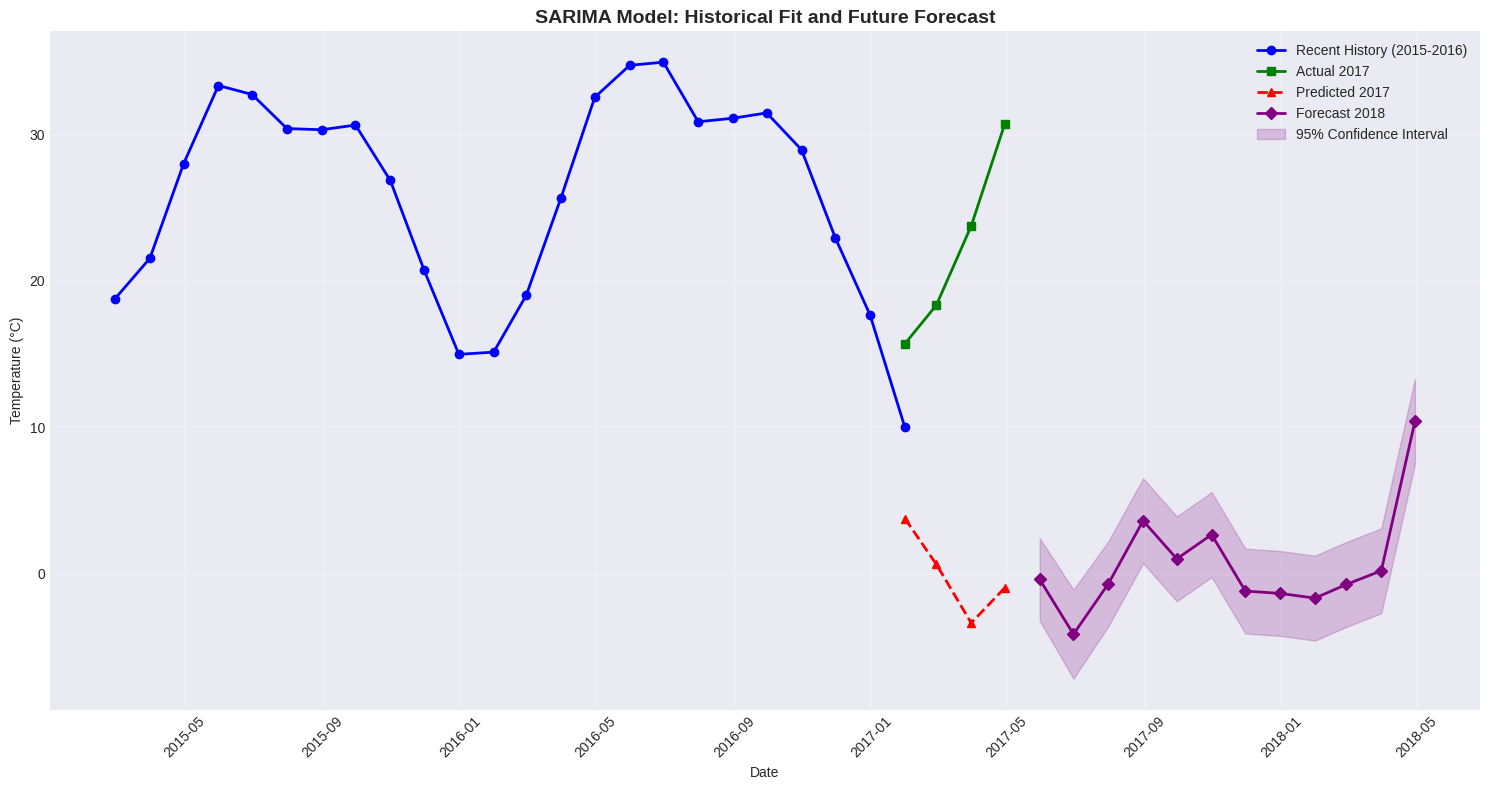


📊 FUTURE FORECAST (Next 12 months):
            Forecasted Temperature (°C)  Lower Bound (95% CI)  \
2017-05-31                        -0.39                 -3.21   
2017-06-30                        -4.13                 -7.17   
2017-07-31                        -0.69                 -3.59   
2017-08-31                         3.62                  0.72   
2017-09-30                         1.02                 -1.88   
2017-10-31                         2.68                 -0.22   
2017-11-30                        -1.18                 -4.08   
2017-12-31                        -1.34                 -4.24   
2018-01-31                        -1.66                 -4.56   
2018-02-28                        -0.72                 -3.62   
2018-03-31                         0.21                 -2.69   
2018-04-30                        10.43                  7.53   

            Upper Bound (95% CI)  
2017-05-31                  2.43  
2017-06-30                 -1.09  
2017-07-31  

In [66]:
future_steps = 12
future_forecast = sarima_model.get_forecast(steps=future_steps)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

# Create future dates
last_date = monthly_test.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                            periods=future_steps, freq='M')
future_mean.index = future_dates
future_ci.index = future_dates

# Plot future forecast
plt.figure(figsize=(15, 8))
plt.plot(monthly_temp.index[-24:], monthly_temp[-24:],
         label='Recent History (2015-2016)', color='blue', linewidth=2, marker='o')
plt.plot(monthly_test.index, monthly_test,
         label='Actual 2017', color='green', linewidth=2, marker='s')
plt.plot(predictions.index, predictions,
         label='Predicted 2017', color='red', linestyle='--', linewidth=2, marker='^')
plt.plot(future_mean.index, future_mean,
         label='Forecast 2018', color='purple', linewidth=2, marker='D')
plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 color='purple', alpha=0.2, label='95% Confidence Interval')

plt.title('SARIMA Model: Historical Fit and Future Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📊 FUTURE FORECAST (Next 12 months):")
future_forecast_df = pd.DataFrame({
    'Forecasted Temperature (°C)': future_mean.round(2),
    'Lower Bound (95% CI)': future_ci.iloc[:, 0].round(2),
    'Upper Bound (95% CI)': future_ci.iloc[:, 1].round(2)
})
print(future_forecast_df)